# E‑commerce Sales Analysis (RFM Segmentation & CLV)

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project analyses customer behaviour in an e‑commerce setting. Using RFM analysis (Recency, Frequency, Monetary), we segment customers into actionable groups (e.g., champions, loyal, at‑risk). We also estimate Customer Lifetime Value (CLV) to prioritise marketing efforts. The analysis includes 10 publication‑ready visualisations.

## Dataset
- **Source:** UCI Online Retail II (public)
- **Rows:** ~500,000 transactions
- **Columns:** InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country

## Key Steps
1. Data cleaning (remove returns, missing CustomerID)
2. Create revenue and invoice totals
3. Compute RFM scores
4. Segment customers
5. Calculate simple CLV (average revenue per customer)
6. Visualise insights

## Requirements
- pandas, matplotlib, seaborn, numpy, datetime

---

**© 2026 Ibrahim – RFM and CLV analysis.**

### Install & Imports

In [2]:
!pip install -q pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

In [3]:
# Download from public URL (or upload manually)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx"
df = pd.read_excel(url, sheet_name='Year 2010-2011')

print("Dataset shape:", df.shape)
df.head(2)

Dataset shape: (541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Data Cleaning

In [7]:
# Remove rows without CustomerID (can't segment)
df = df.dropna(subset=['Customer ID'])

# Keep only valid Quantity and UnitPrice (>0)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# Remove any remaining outliers (optional)
df = df[df['Revenue'] < df['Revenue'].quantile(0.99)]

print(f"Cleaned shape: {df.shape}")

Cleaned shape: (393884, 9)


### Monthly Sales Trend

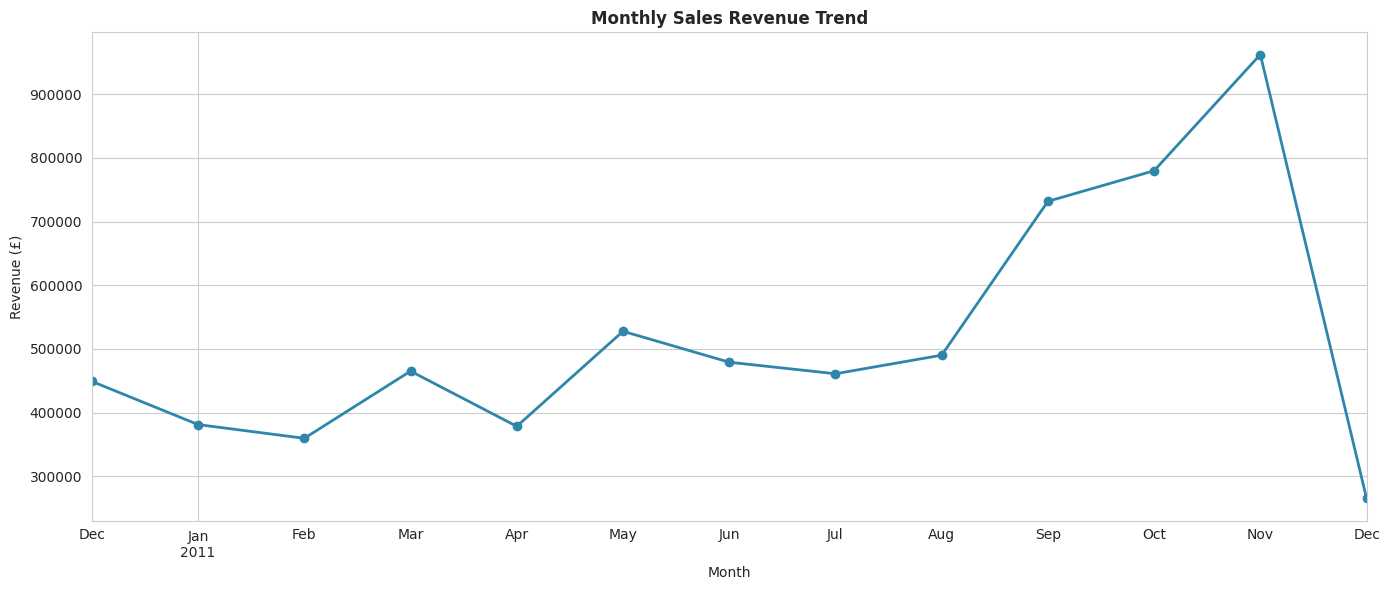

In [8]:
# Aggregate revenue by month
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum()

plt.figure(figsize=(14, 6))
monthly_revenue.plot(marker='o', linewidth=2, color='#2E86AB')
plt.title('Monthly Sales Revenue Trend', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Top 10 Countries by Revenue (excluding UK to see others)

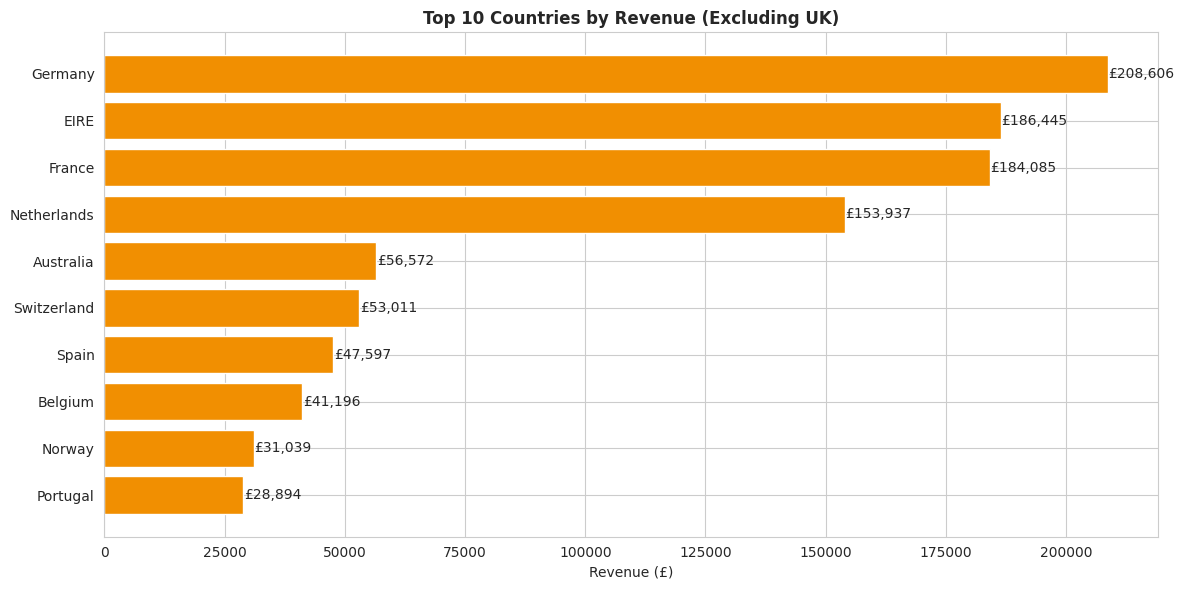

In [9]:
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_rev_excl_uk = country_rev[country_rev.index != 'United Kingdom'].head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(country_rev_excl_uk.index[::-1], country_rev_excl_uk.values[::-1], color='#F18F01')
plt.xlabel('Revenue (£)')
plt.title('Top 10 Countries by Revenue (Excluding UK)', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 100, bar.get_y() + bar.get_height()/2, f'£{width:,.0f}', va='center')
plt.tight_layout()
plt.show()

### Revenue by Hour of Day (Heatmap style)

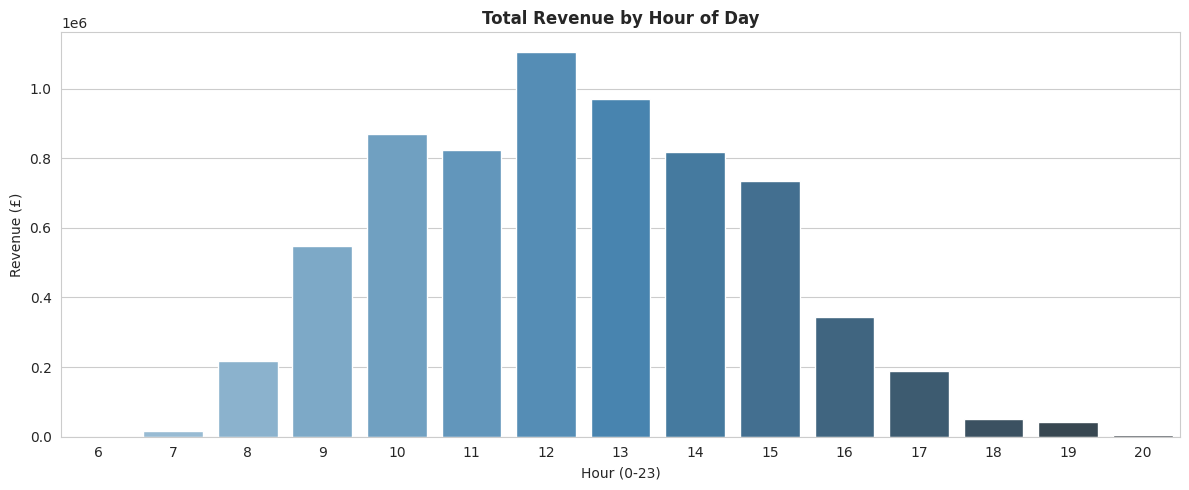

In [10]:
# Extract hour
df['Hour'] = df['InvoiceDate'].dt.hour
hourly_rev = df.groupby('Hour')['Revenue'].sum()

plt.figure(figsize=(12, 5))
sns.barplot(x=hourly_rev.index, y=hourly_rev.values, palette='Blues_d')
plt.title('Total Revenue by Hour of Day', fontweight='bold')
plt.xlabel('Hour (0-23)')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

### Distribution of Invoice Value

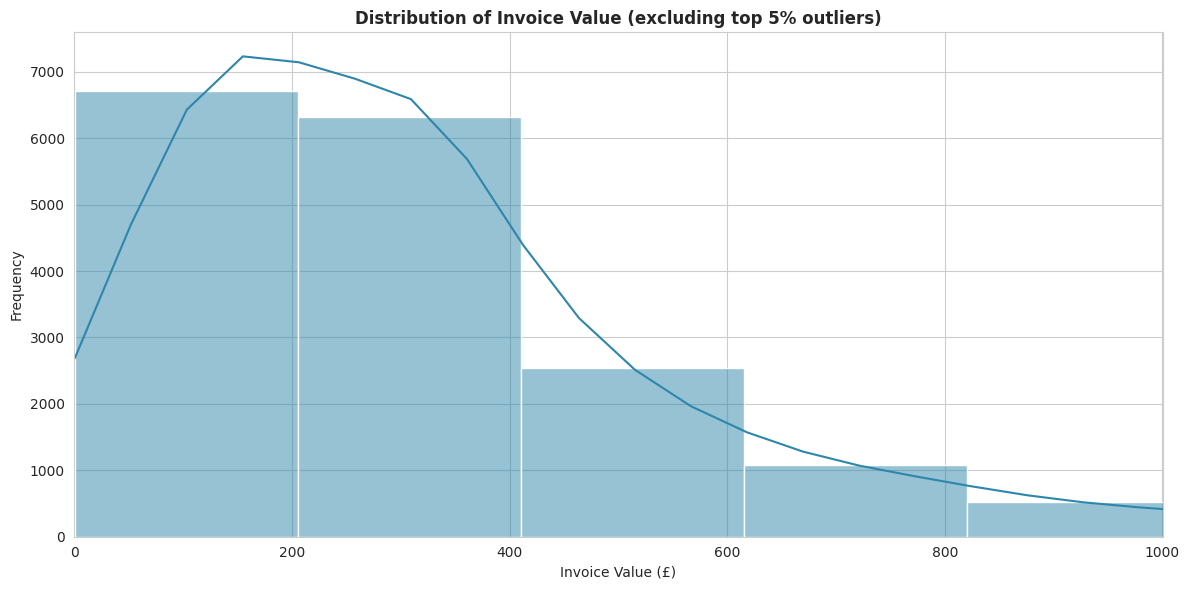

In [12]:
invoice_value = df.groupby('Invoice')['Revenue'].sum()

plt.figure(figsize=(12, 6))
sns.histplot(invoice_value, bins=50, kde=True, color='#2E86AB')
plt.xlim(0, invoice_value.quantile(0.95))
plt.title('Distribution of Invoice Value (excluding top 5% outliers)', fontweight='bold')
plt.xlabel('Invoice Value (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Top 10 Best‑Selling Products

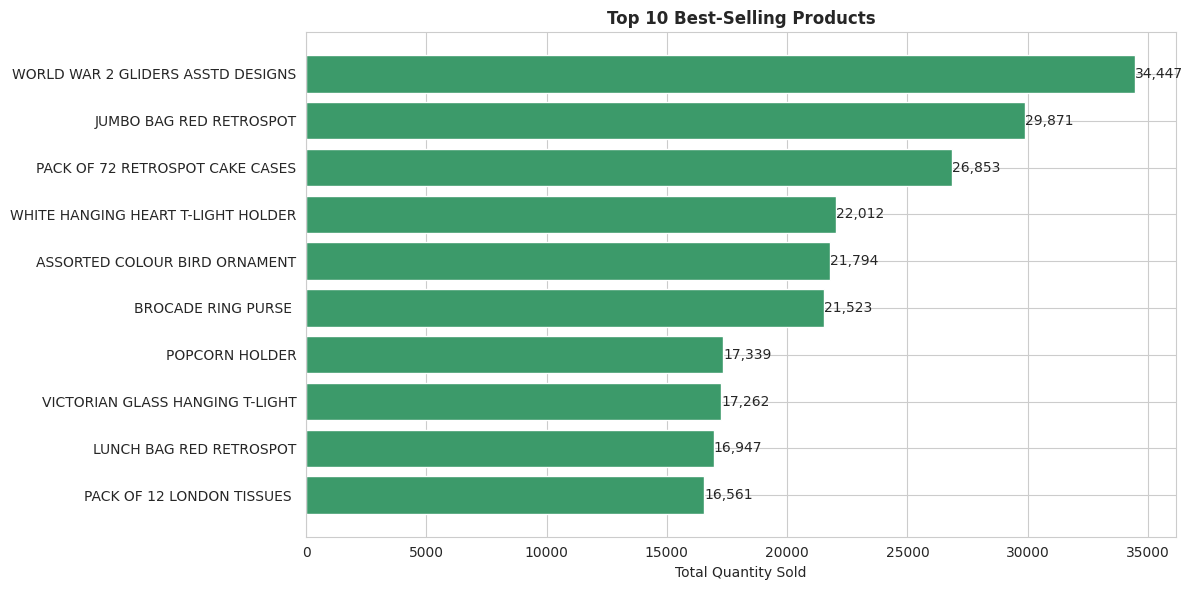

In [13]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_products.index[::-1], top_products.values[::-1], color='#3C9A6A')
plt.xlabel('Total Quantity Sold')
plt.title('Top 10 Best‑Selling Products', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, f'{int(width):,}', va='center')
plt.tight_layout()
plt.show()

### Customer Acquisition by Month

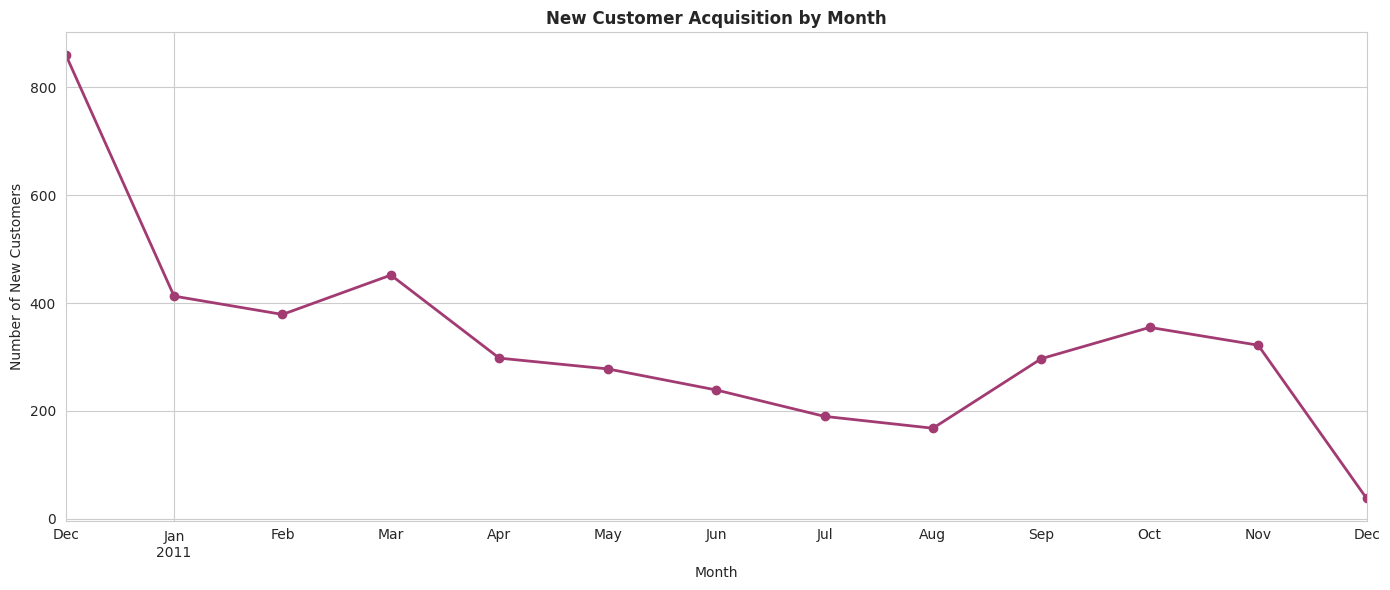

In [15]:
# First purchase date per customer
first_purchase = df.groupby('Customer ID')['InvoiceDate'].min()
first_purchase_month = first_purchase.dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(14, 6))
first_purchase_month.plot(kind='line', marker='o', color='#A23B72', linewidth=2)
plt.title('New Customer Acquisition by Month', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of New Customers')
plt.grid(True)
plt.tight_layout()
plt.show()

### RFM Analysis: Compute Recency, Frequency, Monetary

In [18]:
# Snapshot date (last invoice date + 1 day)
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'nunique',  # Frequency
    'Revenue': 'sum'  # Monetary
}).rename(columns={'InvoiceDate': 'Recency', 'Invoice': 'Frequency', 'Revenue': 'Monetary'})

# Create RFM scores (1-4 quartiles)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=[1,2,3,4])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head())

             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Segment
Customer ID                                                                  
12347.0            2          7   4060.40       4       4       4         444
12348.0           75          4   1557.24       2       3       3         233
12349.0           19          1   1457.55       3       1       3         313
12350.0          310          1    334.40       1       1       2         112
12352.0           36          8   1849.49       3       4       4         344


### RFM Scatter (Recency vs Monetary)

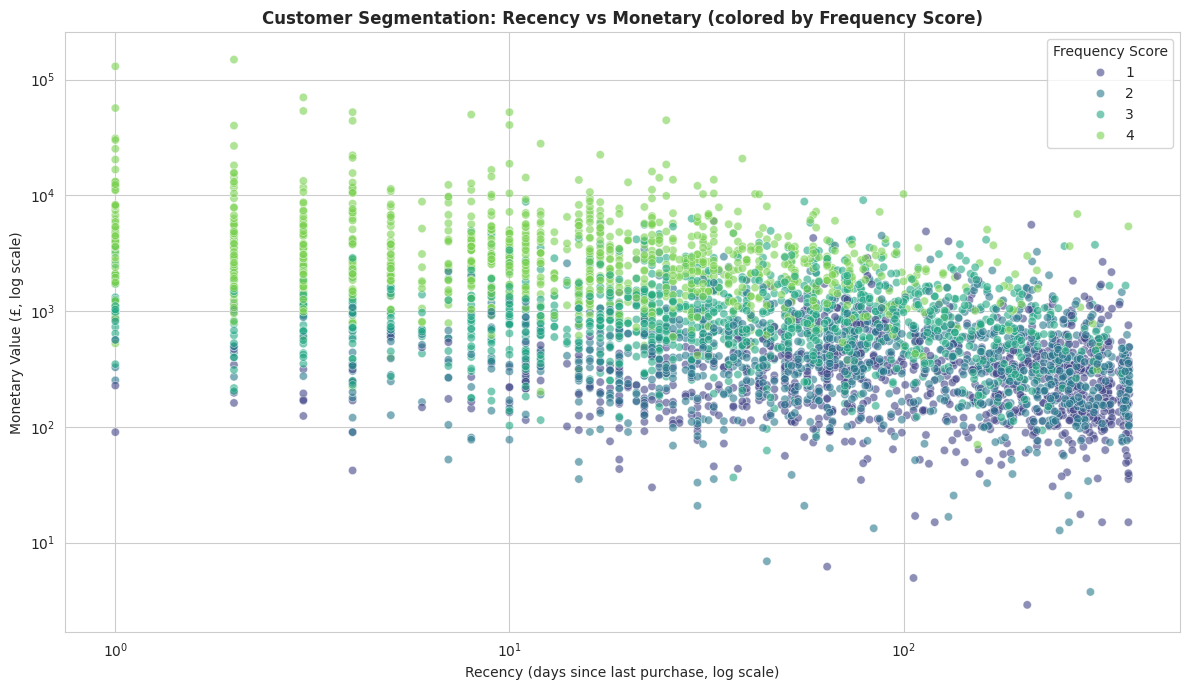

In [19]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='F_Score', palette='viridis', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title('Customer Segmentation: Recency vs Monetary (colored by Frequency Score)', fontweight='bold')
plt.xlabel('Recency (days since last purchase, log scale)')
plt.ylabel('Monetary Value (£, log scale)')
plt.legend(title='Frequency Score')
plt.tight_layout()
plt.show()

### CLV by Customer Segment (Box Plot)

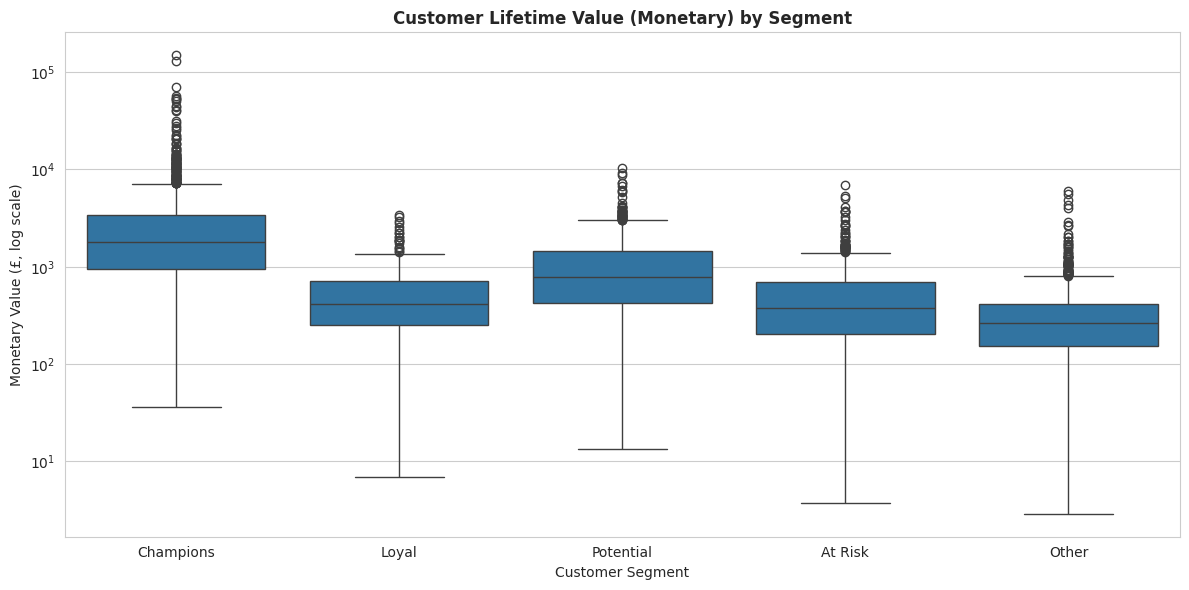

In [22]:
# Assign segment labels based on R_Score and F_Score
def segment_label(row):
    if row['R_Score'] in [4,3] and row['F_Score'] in [4,3]:
        return 'Champions'
    elif row['R_Score'] in [4,3] and row['F_Score'] == 2:
        return 'Loyal'
    elif row['R_Score'] == 2 and row['F_Score'] in [4,3,2]:
        return 'Potential'
    elif row['R_Score'] == 1 and row['F_Score'] in [4,3,2]:
        return 'At Risk'
    else:
        return 'Other'

rfm['Segment'] = rfm.apply(segment_label, axis=1)

plt.figure(figsize=(12, 6))
sns.boxplot(data=rfm, x='Segment', y='Monetary', order=['Champions', 'Loyal', 'Potential', 'At Risk', 'Other'])
plt.yscale('log')
plt.title('Customer Lifetime Value (Monetary) by Segment', fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Monetary Value (£, log scale)')
plt.tight_layout()
plt.show()

### Revenue Contribution by Segment (Donut Chart)

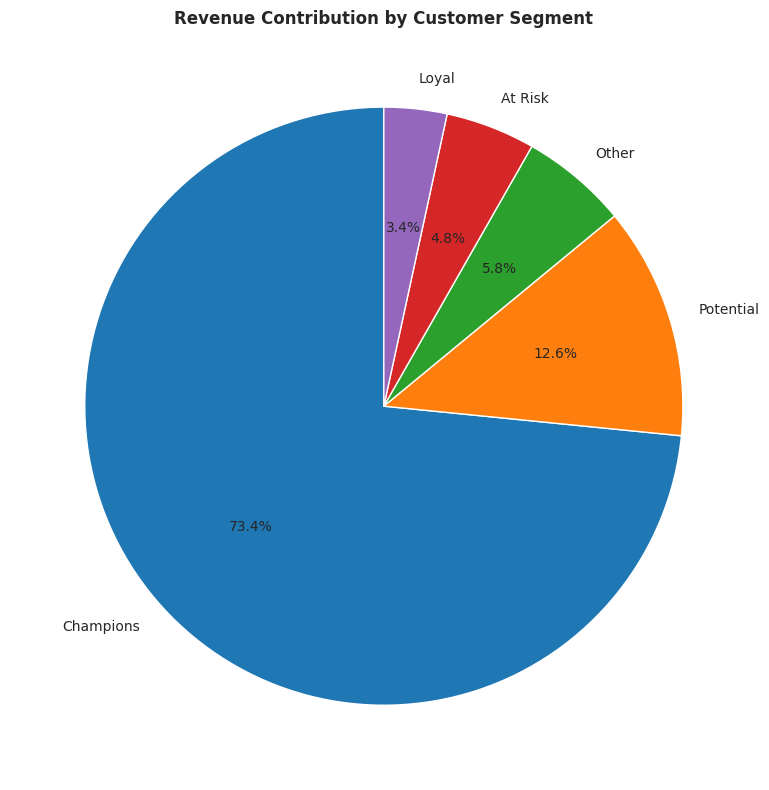

In [23]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(segment_revenue.values, labels=segment_revenue.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.tab10.colors)
plt.title('Revenue Contribution by Customer Segment', fontweight='bold')
plt.tight_layout()
plt.show()

### Heatmap of Average Monetary by Country (Top 10)

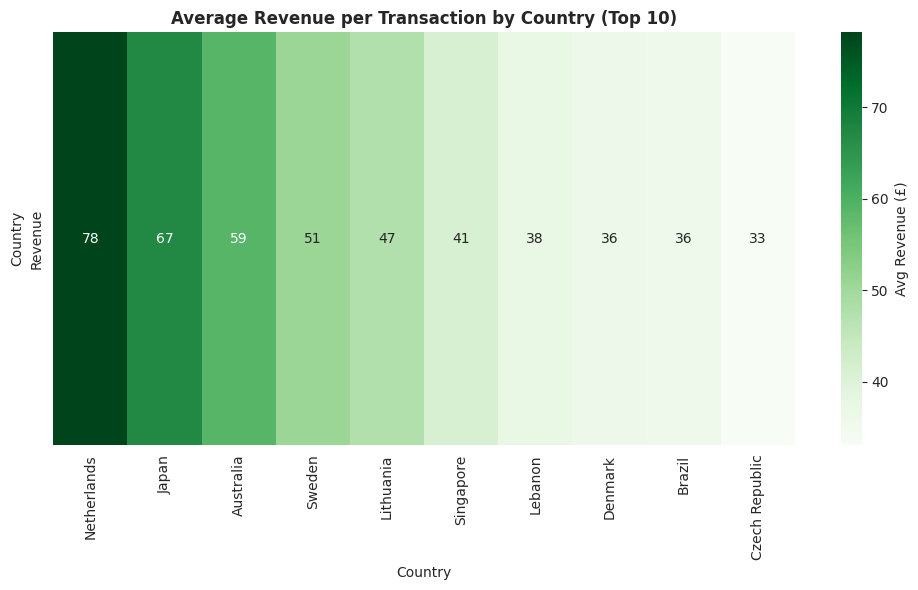

In [24]:
country_monetary = df.groupby('Country')['Revenue'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.heatmap(country_monetary.to_frame().T, annot=True, fmt='.0f', cmap='Greens', cbar_kws={'label': 'Avg Revenue (£)'})
plt.title('Average Revenue per Transaction by Country (Top 10)', fontweight='bold')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Key Insights Summary

In [25]:
print(" Key Insights from E‑commerce RFM & CLV Analysis")
print(f" Total customers: {rfm.shape[0]}")
print(f" Total revenue: £{df['Revenue'].sum():,.2f}")
print(f" Best segment: Champions contribute {segment_revenue['Champions']/segment_revenue.sum()*100:.1f}% of revenue")
print(f" Top product: {top_products.index[0]}")
print(f" Highest non‑UK revenue: {country_rev_excl_uk.index[0]}")
print("\n 10 professional visualisations generated.")
print(" RFM segmentation ready for marketing campaigns.")

 Key Insights from E‑commerce RFM & CLV Analysis
 Total customers: 4290
 Total revenue: £6,730,601.16
 Best segment: Champions contribute 73.4% of revenue
 Top product: WORLD WAR 2 GLIDERS ASSTD DESIGNS
 Highest non‑UK revenue: Germany

 10 professional visualisations generated.
 RFM segmentation ready for marketing campaigns.


### Final Summary

In [26]:
print("E‑commerce RFM & CLV Analysis - COMPLETED")
print("Author: Ibrahim")
print("Dataset cleaned and analysed.")
print("RFM scores computed; customer segments identified.")
print("CLV distribution visualised by segment.")
print("Ready for strategic recommendations.")

E‑commerce RFM & CLV Analysis - COMPLETED
Author: Ibrahim
Dataset cleaned and analysed.
RFM scores computed; customer segments identified.
CLV distribution visualised by segment.
Ready for strategic recommendations.
